# Lección 3 — Combinación de estimadores

**Repositorio:** `deep-learning-complete-guide`  
**Objetivo:** Comprender y entender aspectos importantes sobre los estimadores: Ensembles, Bagging, Random Forest, AdaBoost, SAMME y Gradient Boosting

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Cómo usar este notebook

Este notebook resume el **Tema 3: Combinación de estimadores** con un enfoque práctico:

- primero se explica la intuición de cada método;
- después se bajan las ideas a fórmulas y cálculo;
- luego se implementan ejemplos en Python;
- finalmente se resuelven ejercicios tipo examen.

Los bloques están diseñados para verse correctamente tanto en **modo claro** como en **modo oscuro**.

</div>

## 0. Objetivos del tema

Al terminar este notebook deberías poder:

1. Explicar por qué combinar estimadores puede mejorar un modelo individual.
2. Diferenciar claramente **Bagging**, **Random Forest** y **Boosting**.
3. Implementar un Bagging sencillo con árboles de decisión.
4. Entender el papel de los pesos en **AdaBoost**.
5. Relacionar **AdaBoost** con la pérdida exponencial y el margen.
6. Entender la idea de **Gradient Boosting** como ajuste iterativo de residuos o gradientes.
7. Resolver preguntas tipo examen sobre combinación de estimadores.

## 1. Imports y configuración

Usaremos `NumPy`, `Matplotlib` y `Scikit-learn`. Los ejemplos se construyen con datos sintéticos para que el notebook sea reproducible y se pueda subir a GitHub sin depender de ficheros externos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from math import comb
from collections import Counter

from sklearn.datasets import make_moons, make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
)
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Idea general: ¿por qué combinar estimadores?

Un **estimador** es un modelo que produce una salida a partir de una entrada. En clasificación, por ejemplo, un estimador devuelve una clase; en regresión, devuelve un valor continuo.

La idea de los **ensembles** es combinar varios modelos para obtener un modelo final más robusto.

Hay dos grandes familias:

| Técnica | Idea principal | Suele actuar sobre |
|---|---|---|
| **Bagging** | Entrenar muchos modelos en muestras distintas y votar/promediar | Varianza |
| **Random Forest** | Bagging de árboles + aleatoriedad en características | Varianza |
| **Boosting** | Entrenar modelos secuencialmente corrigiendo errores anteriores | Sesgo y a veces varianza |
| **Gradient Boosting** | Añadir modelos que aproximan el gradiente negativo de la pérdida | Sesgo |

<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Idea clave

Un ensemble funciona bien cuando los modelos individuales cometen errores diferentes. Si todos los modelos fallan exactamente en los mismos ejemplos, combinarlos no aporta demasiado.

</div>

## 3. Votación de la mayoría

Supongamos que entrenamos $K$ clasificadores. Para clasificar una nueva muestra, cada clasificador vota una clase y se escoge la más votada.

Si cada clasificador tiene una tasa de error $p$ y los errores son independientes, la probabilidad de que el ensemble falle es la probabilidad de que se equivoquen más de la mitad de los clasificadores:

$$
P(\text{fallo ensemble}) = \sum_{i=\lceil K/2 \rceil}^{K} \binom{K}{i}p^i(1-p)^{K-i}
$$

Esto explica por qué muchos clasificadores "algo buenos" pueden producir un clasificador conjunto bastante mejor.

In [2]:
def majority_vote_error(k: int, p_error: float) -> float:
    """Probabilidad de que una votación mayoritaria falle.

    k: número de clasificadores, idealmente impar.
    p_error: probabilidad de error individual de cada clasificador.
    """
    min_wrong = k // 2 + 1
    return sum(
        comb(k, i) * (p_error ** i) * ((1 - p_error) ** (k - i))
        for i in range(min_wrong, k + 1)
    )

k = 25
p_error = 0.35
ensemble_error = majority_vote_error(k, p_error)

print(f"Error individual: {p_error:.3f}")
print(f"Error del ensemble con K={k}: {ensemble_error:.4f}")
print(f"Accuracy del ensemble: {1 - ensemble_error:.4f}")

Error individual: 0.350
Error del ensemble con K=25: 0.0604
Accuracy del ensemble: 0.9396


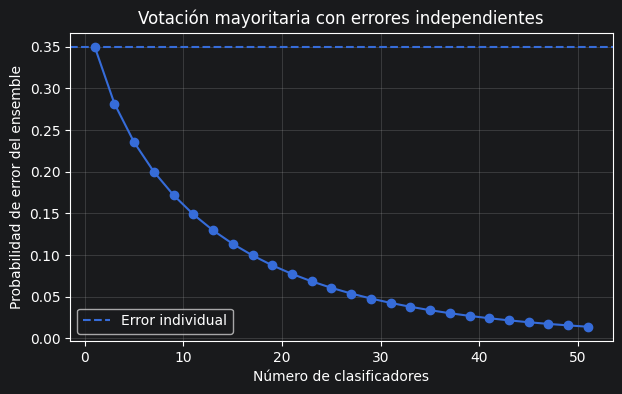

In [3]:
ks = np.arange(1, 52, 2)
errors = [majority_vote_error(int(k), p_error) for k in ks]

plt.figure(figsize=(7, 4))
plt.plot(ks, errors, marker="o")
plt.axhline(p_error, linestyle="--", label="Error individual")
plt.xlabel("Número de clasificadores")
plt.ylabel("Probabilidad de error del ensemble")
plt.title("Votación mayoritaria con errores independientes")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="background:rgba(191,144,0,0.15);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Condición importante

La mejora anterior depende de una hipótesis muy fuerte: que los errores sean aproximadamente independientes. Si todos los clasificadores son iguales o están muy correlacionados, la votación no reduce mucho el error.

</div>

## 4. Recordatorio: árboles de decisión

Los árboles de decisión dividen el espacio de características en regiones. En clasificación, cada región devuelve una clase; en regresión, normalmente devuelve la media de los valores de entrenamiento que caen en esa región.

Formalmente, un árbol puede verse como:

$$
T(x;\theta)=\sum_{j=1}^{N_R}\gamma_j I(x \in R_j)
$$

Donde:

- $R_j$ son las regiones creadas por el árbol;
- $\gamma_j$ es la salida asociada a cada región;
- $I(x \in R_j)$ vale 1 si $x$ cae en la región $R_j$ y 0 en caso contrario.

### 4.1 Entropía e información en árboles de clasificación

Una forma típica de elegir una partición es medir cuánto reduce el desorden de las clases.

La **entropía** de un conjunto $A$ es:

$$
H(A)=-\sum_k p_k^A \log(p_k^A)
$$

La **ganancia de información** al dividir un conjunto $S$ en dos subconjuntos $S_{izq}$ y $S_{der}$ es:

$$
IE = H(S) - \frac{|S_{izq}|}{|S|}H(S_{izq}) - \frac{|S_{der}|}{|S|}H(S_{der})
$$

In [4]:
def entropy(labels):
    labels = np.asarray(labels)
    _, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-12))

parent = np.array([0, 0, 0, 1, 1, 1, 1, 1])
left = np.array([0, 0, 0, 1])
right = np.array([1, 1, 1, 1])

h_parent = entropy(parent)
h_left = entropy(left)
h_right = entropy(right)
info_gain = h_parent - (len(left) / len(parent)) * h_left - (len(right) / len(parent)) * h_right

print(f"H(S)       = {h_parent:.3f}")
print(f"H(S_izq)   = {h_left:.3f}")
print(f"H(S_der)   = {h_right:.3f}")
print(f"Ganancia   = {info_gain:.3f}")

H(S)       = 0.954
H(S_izq)   = 0.811
H(S_der)   = -0.000
Ganancia   = 0.549


### 4.2 Ventajas y limitaciones de los árboles

| Aspecto | Comentario |
|---|---|
| Ventaja | Son rápidos, interpretables y no necesitan demasiada preparación de datos. |
| Ventaja | Pueden modelar relaciones no lineales. |
| Problema | Un árbol profundo puede conseguir casi 100% en entrenamiento. |
| Problema | Tienden a tener **bajo sesgo** pero **alta varianza**. |

Precisamente por esa alta varianza, los árboles son candidatos ideales para **Bagging** y **Random Forest**.

## 5. Bagging: Bootstrap Aggregating

**Bagging** significa **Bootstrap Aggregating**.

La idea es:

1. A partir del conjunto de entrenamiento original de $N$ muestras, generamos varias muestras bootstrap.
2. Cada muestra bootstrap se obtiene eligiendo $N$ ejemplos **con reemplazamiento**.
3. Entrenamos un modelo base en cada muestra.
4. Para inferencia:
   - en clasificación: votación mayoritaria;
   - en regresión: promedio de predicciones.

El objetivo principal es **reducir la varianza**.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Bootstrap

Una muestra bootstrap tiene el mismo tamaño que el conjunto original, pero se genera con reemplazamiento. Por eso algunos ejemplos pueden aparecer varias veces y otros pueden no aparecer.

</div>

In [5]:
# Ejemplo visual sencillo de bootstrap
indices_originales = np.arange(10)
bootstrap = np.random.choice(indices_originales, size=len(indices_originales), replace=True)

print("Índices originales: ", indices_originales)
print("Muestra bootstrap:  ", bootstrap)
print("Ejemplos no usados: ", sorted(set(indices_originales) - set(bootstrap)))

Índices originales:  [0 1 2 3 4 5 6 7 8 9]
Muestra bootstrap:   [6 3 7 4 6 9 2 6 7 4]
Ejemplos no usados:  [np.int64(0), np.int64(1), np.int64(5), np.int64(8)]


### 5.1 Bagging desde cero con árboles de decisión

Este bloque implementa exactamente la idea que suele aparecer en examen:

- `bagging_fit(x, y, n_estimators)`: entrena varios árboles con muestras bootstrap.
- `bagging_predict(x, clfs)`: predice con todos los árboles y devuelve la moda.

In [6]:
def moda(y_hat, axis=1):
    """Calcula la moda en un array 2D de etiquetas enteras."""
    return np.apply_along_axis(
        lambda x: np.bincount(x.astype(int)).argmax(),
        axis=axis,
        arr=y_hat,
    )


def bagging_fit(x, y, n_estimators=10, random_state=42):
    """Entrena un ensemble Bagging usando DecisionTreeClassifier.

    Parameters
    ----------
    x : np.ndarray, shape (n_samples, n_features)
        Datos de entrenamiento.
    y : np.ndarray, shape (n_samples,)
        Etiquetas de entrenamiento.
    n_estimators : int
        Número de árboles.
    random_state : int
        Semilla para reproducibilidad.

    Returns
    -------
    clfs : list
        Lista de árboles entrenados.
    """
    rng = np.random.default_rng(random_state)
    n_samples = x.shape[0]
    clfs = []

    for _ in range(n_estimators):
        bootstrap_idx = rng.choice(n_samples, size=n_samples, replace=True)
        x_boot = x[bootstrap_idx]
        y_boot = y[bootstrap_idx]

        clf = DecisionTreeClassifier(random_state=random_state)
        clf.fit(x_boot, y_boot)
        clfs.append(clf)

    return clfs


def bagging_predict(x, clfs):
    """Predice usando votación mayoritaria de los clasificadores entrenados."""
    predictions = np.column_stack([clf.predict(x) for clf in clfs])
    y_pred = moda(predictions, axis=1)
    return y_pred

In [7]:
X, y = make_moons(n_samples=600, noise=0.30, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

single_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
single_tree.fit(X_train, y_train)
y_pred_tree = single_tree.predict(X_test)

clfs = bagging_fit(X_train, y_train, n_estimators=30, random_state=RANDOM_STATE)
y_pred_bagging = bagging_predict(X_test, clfs)

print(f"Accuracy árbol individual: {accuracy_score(y_test, y_pred_tree):.3f}")
print(f"Accuracy bagging manual:  {accuracy_score(y_test, y_pred_bagging):.3f}")

Accuracy árbol individual: 0.872
Accuracy bagging manual:  0.900


### 5.2 Comparación visual: árbol individual vs Bagging

El siguiente código dibuja la frontera de decisión. La frontera de un árbol individual suele ser más irregular; al combinar muchos árboles, Bagging tiende a estabilizar la decisión.

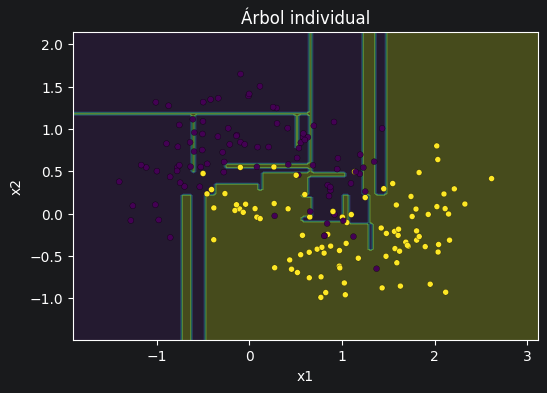

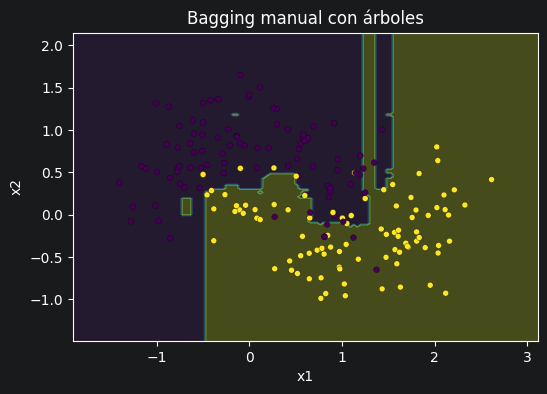

In [8]:
def plot_decision_boundary(model_predict, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 140),
        np.linspace(y_min, y_max, 140),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model_predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=18, edgecolor="k", linewidth=0.2)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary(single_tree.predict, X_test, y_test, "Árbol individual")
plot_decision_boundary(lambda z: bagging_predict(z, clfs), X_test, y_test, "Bagging manual con árboles")

## 6. Random Forest

Un **Random Forest** es, en esencia, un Bagging de árboles de decisión con más aleatoriedad.

Introduce diversidad entre árboles mediante:

1. muestras bootstrap de los datos;
2. selección aleatoria de subconjuntos de características en cada división;
3. árboles normalmente profundos y de alta varianza, que luego se estabilizan al promediar/votar.

En clasificación, la salida final se obtiene por votación mayoritaria.

<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Resumen rápido

Bagging reduce la varianza combinando modelos entrenados en muestras bootstrap. Random Forest añade además aleatoriedad en las características para hacer que los árboles estén menos correlacionados.

</div>

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Accuracy árbol individual: {accuracy_score(y_test, y_pred_tree):.3f}")
print(f"Accuracy bagging manual:  {accuracy_score(y_test, y_pred_bagging):.3f}")
print(f"Accuracy random forest:   {accuracy_score(y_test, y_pred_rf):.3f}")

Accuracy árbol individual: 0.872
Accuracy bagging manual:  0.900
Accuracy random forest:   0.889


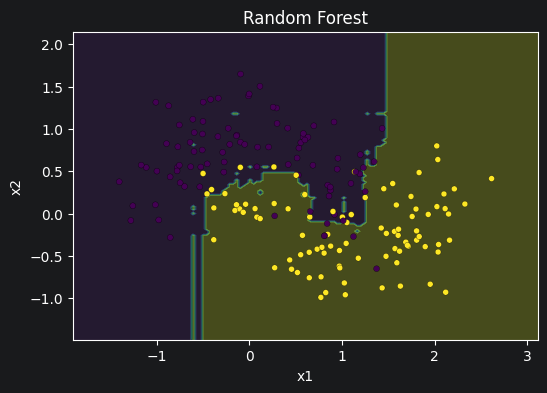

In [10]:
plot_decision_boundary(rf.predict, X_test, y_test, "Random Forest")

### 6.1 Parámetros importantes en Random Forest

| Parámetro | Efecto principal |
|---|---|
| `n_estimators` | Número de árboles. Más árboles suelen reducir varianza, pero aumentan coste. |
| `max_depth` | Profundidad máxima. Controla la complejidad de cada árbol. |
| `max_features` | Número de características candidatas en cada split. Aumenta diversidad entre árboles. |
| `bootstrap` | Activa/desactiva muestreo bootstrap. |

En términos de examen:

- muchos árboles ayudan a reducir varianza;
- árboles demasiado poco profundos pueden aumentar el sesgo;
- árboles profundos tienen baja bias pero alta variance individual;
- el bosque reduce la varianza agregando muchos árboles.

## 7. Boosting

A diferencia de Bagging, Boosting no entrena todos los modelos de forma independiente.

En Boosting:

1. se entrena un primer clasificador débil;
2. se observan sus errores;
3. el siguiente clasificador presta más atención a los ejemplos problemáticos;
4. se repite el proceso;
5. se combinan todos los clasificadores débiles en un clasificador fuerte.

El objetivo habitual es reducir el **sesgo** de modelos débiles.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Clasificador débil

Un clasificador débil no tiene por qué ser muy bueno. Basta con que sea ligeramente mejor que el azar. En AdaBoost se suelen usar stumps, árboles de decisión de profundidad 1.

</div>

## 8. AdaBoost binario

AdaBoost trabaja, en su versión binaria clásica, con etiquetas:

$$
y_i \in \{-1, +1\}
$$

El clasificador fuerte es una suma ponderada de clasificadores débiles:

$$
G(x)=\text{signo}\left(\sum_{m=1}^{M}\alpha_m G_m(x)\right)
$$

Donde:

- $G_m(x)$ es el clasificador débil de la iteración $m$;
- $\alpha_m$ mide la importancia de ese clasificador;
- clasificadores con menor error reciben mayor peso.

### 8.1 Peso del clasificador débil

En AdaBoost discreto, una forma habitual de medir la importancia del clasificador débil es:

$$
\alpha_m = \log\left(\frac{1-err_m}{err_m}\right)
$$

Interpretación:

- si $err_m$ es pequeño, $\alpha_m$ es grande;
- si $err_m = 0.5$, entonces $\alpha_m = 0$;
- si $err_m > 0.5$, el clasificador es peor que azar y no interesa tal como está.

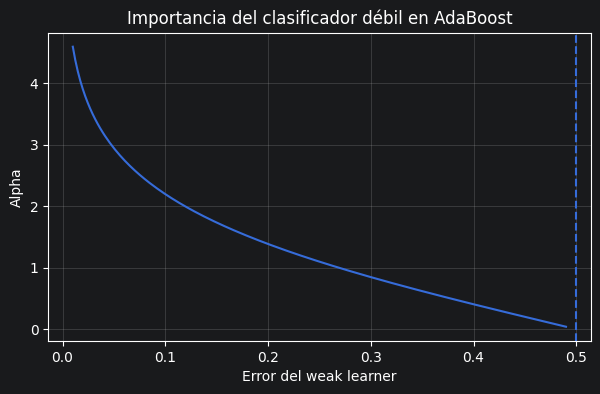

In [11]:
errs = np.linspace(0.01, 0.49, 200)
alphas = np.log((1 - errs) / errs)

plt.figure(figsize=(7, 4))
plt.plot(errs, alphas)
plt.axvline(0.5, linestyle="--")
plt.xlabel("Error del weak learner")
plt.ylabel("Alpha")
plt.title("Importancia del clasificador débil en AdaBoost")
plt.grid(alpha=0.3)
plt.show()

### 8.2 Actualización de pesos de los ejemplos

AdaBoost mantiene pesos sobre los ejemplos de entrenamiento.

La intuición es:

- si un ejemplo se clasifica bien, su peso relativo baja;
- si se clasifica mal, su peso relativo sube;
- el siguiente clasificador se centra más en los ejemplos difíciles.

Por eso, a medida que avanza AdaBoost, los weak learners se enfrentan a ejemplos cada vez más complicados.

In [12]:
# Ejemplo de entrenamiento con AdaBoost en sklearn
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    n_estimators=60,
    learning_rate=0.5,
    random_state=RANDOM_STATE,
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print(f"Accuracy AdaBoost: {accuracy_score(y_test, y_pred_ada):.3f}")

Accuracy AdaBoost: 0.889


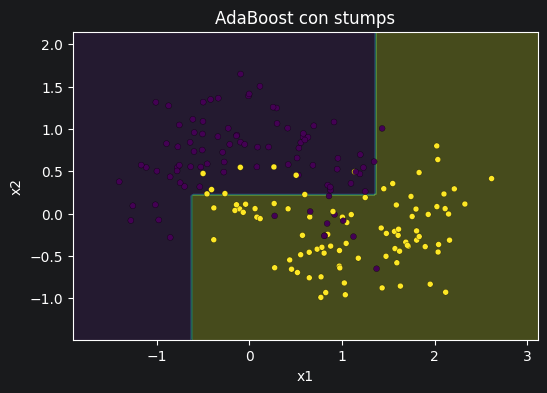

In [13]:
plot_decision_boundary(ada.predict, X_test, y_test, "AdaBoost con stumps")

### 8.3 AdaBoost y el margen

Para clasificación binaria con $y \in \{-1,+1\}$, el **margen** se define como:

$$
y \cdot f(x)
$$

Interpretación:

| Margen | Significado |
|---|---|
| $y f(x) > 0$ | Clasificación correcta |
| $y f(x) < 0$ | Clasificación incorrecta |
| margen grande positivo | Clasificación correcta y segura |
| margen muy negativo | Error grave |

AdaBoost está muy relacionado con la pérdida exponencial:

$$
L(y, f(x)) = e^{-y f(x)}
$$

Esta pérdida penaliza muchísimo los ejemplos mal clasificados con margen negativo.

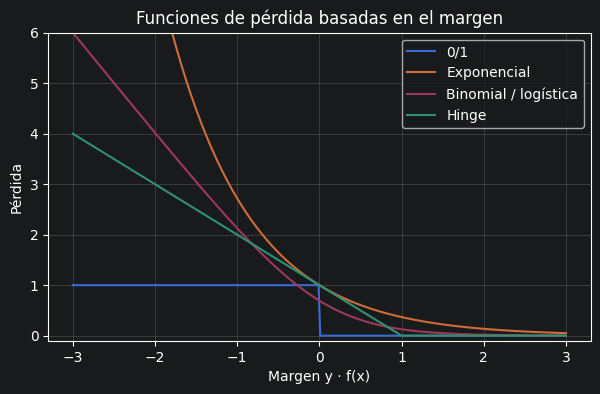

In [14]:
margin = np.linspace(-3, 3, 300)
loss_01 = (margin < 0).astype(float)
loss_exp = np.exp(-margin)
loss_logistic = np.log(1 + np.exp(-2 * margin))
loss_hinge = np.maximum(0, 1 - margin)

plt.figure(figsize=(7, 4))
plt.plot(margin, loss_01, label="0/1")
plt.plot(margin, loss_exp, label="Exponencial")
plt.plot(margin, loss_logistic, label="Binomial / logística")
plt.plot(margin, loss_hinge, label="Hinge")
plt.ylim(-0.1, 6)
plt.xlabel("Margen y · f(x)")
plt.ylabel("Pérdida")
plt.title("Funciones de pérdida basadas en el margen")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<div style="background:rgba(191,144,0,0.15);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Cuidado con outliers

La pérdida exponencial crece muy rápido cuando el margen es negativo. Por eso AdaBoost puede comportarse peor si hay etiquetas erróneas o clases no separables.

</div>

## 9. SAMME: AdaBoost multiclase

SAMME extiende AdaBoost a clasificación multiclase.

Sus siglas significan:

**Stagewise Additive Modeling using Multi-class Exponential loss function**.

La diferencia importante frente a AdaBoost binario es que ahora hay $K$ clases. El peso del clasificador débil incorpora una corrección con $K$:

$$
\alpha_m = \log\left(\frac{1-err_m}{err_m}\right) + \log(K-1)
$$

La condición de clasificador débil pasa a ser:

$$
err_m < 1 - \frac{1}{K}
$$

Es decir, debe hacerlo mejor que una clasificación aleatoria entre $K$ clases.

## 10. Gradient Boosting

Gradient Boosting también construye un modelo aditivo, pero lo interpreta como una optimización de una función de pérdida.

El modelo final tiene forma:

$$
f_M(x)=f_0(x)+\sum_{m=1}^{M}\beta_m b(x;\gamma_m)
$$

La idea es que cada nuevo estimador base $b(x;\gamma_m)$ corrija lo que falta en el modelo anterior.

En regresión con MSE, esto se puede ver como ajustar modelos a los **residuos**.

En pérdidas más generales, se ajusta un modelo al **gradiente negativo** de la pérdida.

<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Idea clave de Gradient Boosting

Cada weak learner se entrena para mejorar la dirección en la que la pérdida baja más. Por eso se llama Gradient Boosting: boosting visto como descenso de gradiente funcional.

</div>

### 10.1 Ejemplo de Gradient Boosting en regresión

Vamos a generar una función no lineal con ruido y comparar:

- un único árbol de regresión poco profundo;
- Gradient Boosting con muchos árboles pequeños.

In [15]:
rng = np.random.default_rng(RANDOM_STATE)
X_reg = np.linspace(0, 1, 250).reshape(-1, 1)
y_true = np.sin(2 * np.pi * X_reg[:, 0])
y_reg = y_true + rng.normal(0, 0.15, size=X_reg.shape[0])

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.30, random_state=RANDOM_STATE
)

single_reg_tree = DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE)
single_reg_tree.fit(Xr_train, yr_train)

# Compatibilidad con versiones nuevas de sklearn: squared ya no existe en algunas versiones.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

gbr = GradientBoostingRegressor(
    n_estimators=120,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE,
)
gbr.fit(Xr_train, yr_train)

pred_tree = single_reg_tree.predict(Xr_test)
pred_gbr = gbr.predict(Xr_test)

print(f"RMSE árbol individual:   {rmse(yr_test, pred_tree):.3f}")
print(f"RMSE Gradient Boosting: {rmse(yr_test, pred_gbr):.3f}")

RMSE árbol individual:   0.323
RMSE Gradient Boosting: 0.143


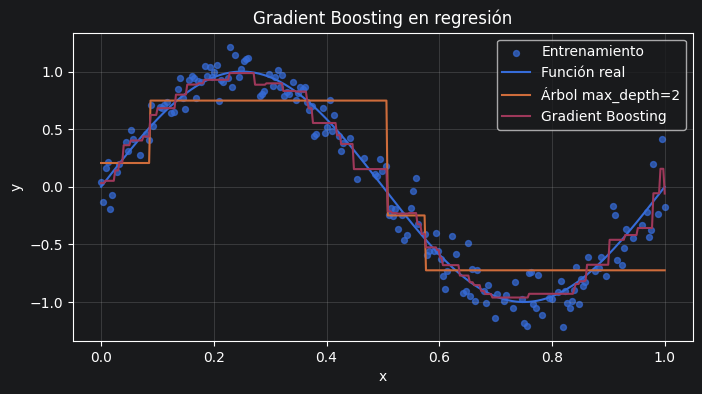

In [16]:
x_grid = np.linspace(0, 1, 400).reshape(-1, 1)

plt.figure(figsize=(8, 4))
plt.scatter(Xr_train[:, 0], yr_train, s=18, label="Entrenamiento", alpha=0.7)
plt.plot(x_grid[:, 0], np.sin(2 * np.pi * x_grid[:, 0]), label="Función real")
plt.plot(x_grid[:, 0], single_reg_tree.predict(x_grid), label="Árbol max_depth=2")
plt.plot(x_grid[:, 0], gbr.predict(x_grid), label="Gradient Boosting")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Gradient Boosting en regresión")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 10.2 Regularización en Gradient Boosting

Gradient Boosting puede sobreajustar si se añaden demasiados árboles o si cada árbol es demasiado complejo.

Métodos habituales de regularización:

| Técnica | Descripción |
|---|---|
| `learning_rate` / shrinkage | Reduce la contribución de cada árbol. |
| `n_estimators` | Número de árboles. Más árboles no siempre es mejor. |
| `max_depth` | Controla la complejidad de cada weak learner. |
| `subsample` | Entrena cada árbol con una proporción de datos sin reemplazamiento. |

Normalmente hay un compromiso entre `learning_rate` y `n_estimators`: learning rate pequeño suele requerir más árboles.

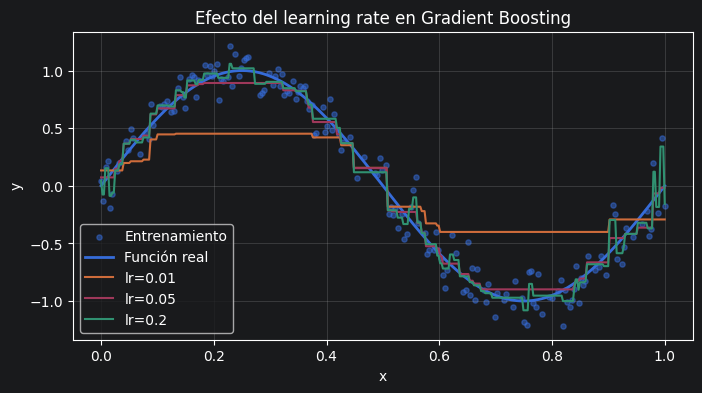

In [17]:
learning_rates = [0.01, 0.05, 0.2]
plt.figure(figsize=(8, 4))
plt.scatter(Xr_train[:, 0], yr_train, s=14, alpha=0.5, label="Entrenamiento")
plt.plot(x_grid[:, 0], np.sin(2 * np.pi * x_grid[:, 0]), linewidth=2, label="Función real")

for lr in learning_rates:
    model = GradientBoostingRegressor(
        n_estimators=80,
        learning_rate=lr,
        max_depth=2,
        random_state=RANDOM_STATE,
    )
    model.fit(Xr_train, yr_train)
    plt.plot(x_grid[:, 0], model.predict(x_grid), label=f"lr={lr}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Efecto del learning rate en Gradient Boosting")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 11. Bagging vs Boosting vs Gradient Boosting

| Método | Entrenamiento | Combinación | Objetivo típico | Modelos base habituales |
|---|---|---|---|---|
| Bagging | Paralelo/independiente | Voto o promedio | Reducir varianza | Árboles profundos |
| Random Forest | Paralelo/independiente | Voto o promedio | Reducir varianza y correlación | Árboles profundos con features aleatorias |
| AdaBoost | Secuencial | Voto ponderado | Reducir sesgo | Stumps o árboles pequeños |
| Gradient Boosting | Secuencial | Suma aditiva | Optimizar una pérdida | Árboles pequeños |

<div style="background:rgba(191,144,0,0.15);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Pregunta típica de examen

Bagging suele ayudar a modelos de alta varianza como árboles de decisión. No suele mejorar tanto modelos de baja varianza como clasificadores lineales simples.

</div>

## 12. Ejercicios tipo test resueltos

A continuación se resuelven las preguntas tipo test del Tema 3.

### Ejercicio 1

**Enunciado resumido:** Dados $N$ datos de entrenamiento, Bagging consiste en una votación de $k$ clasificadores cada uno entrenado...

**Respuesta correcta:** sobre una muestra aleatoria con reemplazamiento sobre los $N$ datos de entrenamiento.

**Justificación:** Bagging utiliza bootstrap. Cada clasificador se entrena con una muestra de tamaño $N$ obtenida con reemplazamiento a partir del conjunto original.

### Ejercicio 2

**Enunciado resumido:** En AdaBoost, el error del $m$-ésimo weak learner tiende a incrementarse a medida que crece $m$. ¿Cuál es la razón?

**Respuesta correcta:** al $m$-ésimo weak learner le quedan los datos más difíciles de clasificar.

**Justificación:** AdaBoost aumenta el peso de los ejemplos mal clasificados. Por tanto, los siguientes weak learners se entrenan prestando más atención a ejemplos más difíciles.

### Ejercicio 3

**Enunciado resumido:** ¿Cuál de estas afirmaciones es incorrecta sobre Random Forest?

Opciones relevantes:

- Cada árbol se puede entrenar con subconjunto aleatorio de características.
- Los árboles tienen que ser de poca profundidad.
- La profundidad del árbol y el número de árboles son parámetros a estimar/elegir.
- Cada árbol se puede entrenar con una muestra aleatoria de los datos.

**Respuesta incorrecta:** los árboles tienen que ser de poca profundidad.

**Justificación:** En Random Forest se suelen usar árboles bastante profundos. Cada árbol individual puede tener alta varianza, y el bosque reduce esa varianza por agregación.

## 13. Problema de Bagging resuelto

El ejercicio pide completar dos funciones:

```python
def bagging_fit(x, y, n_estimators=10):
    ...
    return clfs


def bagging_predict(x, clfs):
    ...
    return y_pred
```

La solución es la misma que hemos implementado antes, pero aquí queda en formato limpio de examen.

In [18]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np


def moda(y_hat, axis=1):
    return np.apply_along_axis(
        lambda x: np.bincount(x.astype(int)).argmax(),
        axis=axis,
        arr=y_hat,
    )


def bagging_fit(x, y, n_estimators=10):
    # x.shape = (n, m), n datos y m características
    # y.shape = (n,), n etiquetas
    n = x.shape[0]
    clfs = []

    for _ in range(n_estimators):
        # Muestra bootstrap: n índices con reemplazamiento
        idx = np.random.choice(n, size=n, replace=True)
        x_boot = x[idx]
        y_boot = y[idx]

        clf = DecisionTreeClassifier()
        clf.fit(x_boot, y_boot)
        clfs.append(clf)

    return clfs


def bagging_predict(x, clfs):
    # Predicciones de todos los clasificadores
    y_hat = np.column_stack([clf.predict(x) for clf in clfs])

    # Votación por mayoría
    y_pred = moda(y_hat, axis=1)

    return y_pred

### Comprobación rápida

In [19]:
np.random.seed(RANDOM_STATE)
clfs_exam = bagging_fit(X_train, y_train, n_estimators=20)
y_pred_exam = bagging_predict(X_test, clfs_exam)
print("Accuracy:", accuracy_score(y_test, y_pred_exam))

Accuracy: 0.8833333333333333


## 14. Mini-cheatsheet del tema

| Concepto | Qué recordar |
|---|---|
| Votación mayoritaria | Funciona mejor si los errores de los modelos son independientes. |
| Bagging | Muestras bootstrap + agregación. Reduce varianza. |
| Random Forest | Bagging de árboles + selección aleatoria de características. |
| Boosting | Modelos secuenciales que corrigen errores anteriores. |
| AdaBoost | Aumenta peso de ejemplos mal clasificados. Usa pérdida exponencial. |
| SAMME | Extensión multiclase de AdaBoost. |
| Gradient Boosting | Ajusta modelos al gradiente negativo de la pérdida. |
| Árbol individual | Bajo sesgo, alta varianza si es profundo. |
| Bosque | Menor varianza por agregación. |

<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Resumen final

Bagging y Random Forest estabilizan modelos de alta varianza. Boosting construye un modelo fuerte añadiendo modelos débiles de forma secuencial. Gradient Boosting generaliza esta idea como optimización de una pérdida mediante pasos en dirección del gradiente negativo.

</div>

## 15. Ejercicios propuestos

1. Cambia el número de estimadores en Bagging y observa cómo cambia la accuracy.
2. Cambia `max_depth` en Random Forest y analiza la frontera de decisión.
3. Prueba AdaBoost con `max_depth=1`, `max_depth=2` y `max_depth=4`.
4. En Gradient Boosting, compara `learning_rate=0.01`, `0.1` y `0.5`.
5. Explica con tus palabras por qué Bagging reduce varianza y AdaBoost tiende a reducir sesgo.